# Introduction
**Diabetes** is a chronic health condition affecting millions of people worldwide. Early detection of individuals at risk can help guide preventative care and improve health outcomes. Machine learning models are increasingly used in healthcare analytics to identify patterns in medical and lifestyle data that may indicate disease risk.

In this project, we'll train a **Multilayer Perceptron (MLP)** neural network to predict whether an individual has diabetes based on a set of health indicators. We'll use two datasets derived from the same source:
1. A **full dataset**, which reflects the natural distribution of the data.
2. A **balanced dataset**, where the number of diabetic and non-diabetic samples is approximately equal.

The goal of this project is to:

- Train neural network classifiers on both datasets to **predict diabete** with health indicators.
- Evaluate how **class imbalance** affects performance.
- Analyze the impact of **hidden layer size** on model accuracy and training time.
- Visualize training performance across epochs.

## Evaluation Criteria
The model will evaluated using the following 2 metrics to determine whether it is performing well:
- **Accuracy.** For a diabetes prediction model to be useful in practice, it should achieve a good accuracy to support meaningful decision-making. For this project, we set the standard to **over 70%**. It's not an extremely high number, since the model we use is rather simple and even if the model is not perfectly accurate, it could still provide value as a screening or risk-assessment tool.
- **Meaningful Comparisons.** The result should compare the performance of both models trained on the 2 datasets and demonstrate the difference clearly. Visualization should be clear, understandable for readers, and meaningful.


## Implications, Risks, and Stakeholders
Using machine learning for health prediction has important implications. A model like this could help **healthcare providers, public health researchers, and patients** better understand diabetes risk and potentially support earlier intervention.

However, there are also risks. If the model performs poorly on certain populations or produces inaccurate predictions, it could lead to **misleading risk assessments**. False negatives could delay treatment, while false positives could cause unnecessary concern or medical testing. Additionally, models trained on survey-based data may not fully capture all relevant medical factors.

Because of these considerations, such models should be viewed as **decision-support tools** rather than diagnostic systems, and their predictions should be interpreted alongside professional medical judgment.

# Dataset
The data used in this project comes from a public dataset available on Kaggle: **[Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)**, which derived from the Behavioral Risk Factor Surveillance System (BRFSS) 2015 survey. BRFSS is a health-related telephone survey on Americans that is collected annually by the CDC (Centers for Disease Control).

Two versions of the dataset were used:

- Full dataset – the original class distribution with all 253,680 survey responses.

- Balanced dataset – a 50/50 split between diabetic and non-diabetic cases with 70,692 survey responses.

### Import Data

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.utils import Bunch
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [38]:
def load_dataset(file_path):
    """
    Load a diabetes dataset from a CSV file and convert it into a
    scikit-learn–style dataset object.

    Parameters
    file_path : str
        Path to the CSV file containing the dataset.

    Returns
    dataset : Bunch
        Dictionary-like object with attributes:
        - data : feature matrix (n_samples, n_features)
        - target : label array (n_samples,)
        - frame : original pandas DataFrame
    """

    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Separate the target column (label) from the feature columns
    target_col = "Diabetes_binary"

    # X = feature matrix (all columns except the target)
    X = df.drop(columns=[target_col]).values

    # y = labels (0 = no diabetes, 1 = diabetes)
    y = df[target_col].values

    # Create a scikit-learn style dataset object
    dataset = Bunch(
        data=X,
        target=y,
        frame=df 
    )

    return dataset

# load both datasets
full_data_file = "data/diabetes_binary_health_indicators_BRFSS2015.csv"
balanced_data_file = "data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
full_data = load_dataset(full_data_file)
balanced_data = load_dataset(balanced_data_file)

# show loaded data of balanced dataset
print(balanced_data['frame'])

       Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                  0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1                  0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2                  0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3                  0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4                  0.0     0.0       0.0        1.0  29.0     1.0     0.0   
...                ...     ...       ...        ...   ...     ...     ...   
70687              1.0     0.0       1.0        1.0  37.0     0.0     0.0   
70688              1.0     0.0       1.0        1.0  29.0     1.0     0.0   
70689              1.0     1.0       1.0        1.0  25.0     0.0     0.0   
70690              1.0     1.0       1.0        1.0  18.0     0.0     0.0   
70691              1.0     1.0       1.0        1.0  25.0     0.0     0.0   

       HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0 

### Dataset Structure

On the table above, each row is a sample that represents one individual and contains several health and lifestyle indicators.

- Target variable
    -   Diabetes_binary:
        - 0: No diabetes
        - 1: Diabetes

- Input features
    - Examples:
        - High blood pressure (HighBP)
        - High cholesterol (HighChol)
        - Cholesterol check (CholCheck)
        - Body Mass Index (BMI)
        - Smoking status (Smoker)
        - ...... (please refer to their original website for more)
    - Each row contains 21 columns of input features.

The target variable is stored into a vector (the true label), and the features are stored into an input matrix, which are shown below:

In [39]:
print(f"output label:")
print(balanced_data['target'])
print("input matrix:")
print(balanced_data['data'])


output label:
[0. 0. 0. ... 1. 1. 1.]
input matrix:
[[ 1.  0.  1. ...  4.  6.  8.]
 [ 1.  1.  1. ... 12.  6.  8.]
 [ 0.  0.  1. ... 13.  6.  8.]
 ...
 [ 1.  1.  1. ... 13.  6.  4.]
 [ 1.  1.  1. ... 11.  2.  4.]
 [ 1.  1.  1. ...  9.  6.  2.]]


### Train–Test Splitting

Instead of using the standard train_test_split function, a custom splitting procedure was implemented which ensures that comparisons between models trained on the full dataset and the balanced dataset are fair and consistent.

1. Randomly select a fixed number of samples for testing (20,000 datapoints, approximately 28.5% of balanced dataset).
2. Ensure these samples exist in both datasets.
3. Remove those samples from the training data.
4. Both models will be evaluated on this exact same test set later.

In [40]:
def split_datasets(full_data, balanced_data, test_size=20000, random_state=42):
    """
    Split training and test datasets for two models trained separately on full and balanced dataset.

    The test set is randomly selected from the overlapping samples between
    the two datasets. These samples are removed from both training datasets.

    Parameters
    full_data : Bunch
        Dataset containing the full dataset.
    balanced_data : Bunch
        Dataset containing the balanced dataset.
    test_size : int
        Number of overlapping samples to use as test data.
    random_state : int
        Seed for reproducible randomness.

    Returns
    X_train_bal, y_train_bal : training data from balanced dataset
    X_train_full, y_train_full : training data from full dataset
    X_test, y_test : shared test dataset
    """

    # Combine features and labels so each row is a full sample
    full_combined = np.column_stack((full_data.data, full_data.target))
    balanced_combined = np.column_stack((balanced_data.data, balanced_data.target))

    # Convert rows to tuples so we can compute intersection
    full_set = set(map(tuple, full_combined))
    balanced_set = set(map(tuple, balanced_combined))

    # Find overlapping samples between datasets
    overlap = np.array(list(full_set.intersection(balanced_set)))

    # Randomly shuffle overlap for unbiased test selection
    rng = np.random.default_rng(random_state)
    rng.shuffle(overlap)

    # Select test samples
    test_samples = overlap[:test_size]

    # Convert test samples to tuple set for quick lookup
    test_set = set(map(tuple, test_samples))

    # Remove test samples from both datasets
    train_full = np.array([row for row in full_combined if tuple(row) not in test_set])
    train_bal = np.array([row for row in balanced_combined if tuple(row) not in test_set])

    # Split features and labels
    X_test = test_samples[:, :-1]
    y_test = test_samples[:, -1]

    X_train_full = train_full[:, :-1]
    y_train_full = train_full[:, -1]

    X_train_bal = train_bal[:, :-1]
    y_train_bal = train_bal[:, -1]

    return X_train_full, y_train_full, X_train_bal, y_train_bal, X_test, y_test

In [41]:
# see if we can run on the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_full, y_train_full, X_train_bal, y_train_bal, X_test, y_test = split_datasets(full_data, balanced_data)

# convert from numpy to pytorch and also move teh data to the GPU
X_train_full = torch.from_numpy(X_train_full.astype(np.float32)).to(device)
y_train_full = torch.from_numpy(y_train_full.astype(np.int64)).to(device)
X_train_bal = torch.from_numpy(X_train_bal.astype(np.float32)).to(device)
y_train_bal = torch.from_numpy(y_train_bal.astype(np.int64)).to(device)
X_test = torch.from_numpy(X_test.astype(np.float32)).to(device)
y_test = torch.from_numpy(y_test.astype(np.int64)).to(device)
input_size = X_train_full.shape[1]
num_classes = 2 # binary

# Training
## Model Architecture
We'll use a Multilayer Perceptron (MLP) model implemented with PyTorch. The neural network contains:

- Input layer
    - Size equal to the number of features.

- Hidden layer
    - Fully connected layer
    - Size varies during experiments, but in first experiment is set to 64.

- Activation function
    - Sigmoid function

- Output layer
    - Two output classes (diabetes / no diabetes).

In [42]:
class MLP(nn.Module):
    """
    Two-layer MLP: input -> hidden -> output logits.

    Parameters
    input_size : int
        Number of input features.
    hidden_size : int
        Number of neurons in the hidden layer.
    num_classes : int
        Number of output classes.
    """
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.linear_1 = nn.Linear(input_size, hidden_size)
        self.linear_2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.linear_1(x)
        out = F.sigmoid(out)
        out = self.linear_2(out)
        return out

## Plot functions
To monitor model training and evaluate performance, several plotting utilities were implemented:

In [43]:
def plot_epoch_loss(n_epochs, train_losses, test_losses, name):
    """
    Plot training and test loss over epochs.

    Parameters
    n_epochs : int
        Number of training epochs.
    train_losses : list or array
        Training loss values for each epoch.
    test_losses : list or array
        Test loss values for each epoch.
    name : str
        Name of the model or experiment.
    """
    plt.figure()
    plt.plot(range(n_epochs), train_losses, label=f'Train Loss ({name})')
    plt.plot(range(n_epochs), test_losses, label=f'Test Loss ({name})')
    plt.title(f'Loss over epochs ({name})')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.show()


def plot_epoch_accuracy(n_epochs, accuracies, name):
    """
    Plot model accuracy over epochs.

    Parameters
    n_epochs : int
        Number of training epochs.
    accuracies : list or array
        Accuracy values for each epoch.
    name : str
        Name of the model or experiment.
    """
    plt.figure()
    plt.plot(range(n_epochs), accuracies, label=f'Accuracy ({name})')
    plt.title(f'Accuracy over epochs ({name})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


def plot_confusion_matrix(model, X_test, y_test, name):
    """
    Compute and plot a 2x2 confusion matrix for model predictions.

    Parameters
    model : torch.nn.Module
        Trained PyTorch model.
    X_test : torch.Tensor
        Test input data.
    y_test : torch.Tensor
        True labels for the test data.
    name : str
        Name of the model or experiment.
    """
    with torch.no_grad():
        outputs = model(X_test)
        preds = outputs.argmax(dim=1)

    y_true = y_test.cpu().numpy()
    y_pred = preds.cpu().numpy()

    # Compute 2x2 confusion matrix
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    # Plot confusion matrix
    plt.figure()
    plt.imshow(cm)
    plt.title(f'Confusion Matrix ({name})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.colorbar()
    plt.show()

## Training Details
The training function implements MLP and used gradient descent with cross-entropy loss. It computes and stores training and test losses, as well as test accuracy, at each epoch in the training loop. Optionally, it plots the loss and accuracy curves. Finally, it returns the trained model and the accuracy history.

In [44]:
def train_mlp(X_train, y_train, X_test, y_test, name, input_size, hidden_size, num_classes, device, plot=True):
    """
    Train a MLP model and track performance.

    Parameters
    X_train : torch.Tensor
        Training features.
    y_train : torch.Tensor
        Training labels.
    X_test : torch.Tensor
        Test features.
    y_test : torch.Tensor
        Test labels.
    name : str
        Model or experiment name for plotting.
    input_size : int
        Number of input features.
    hidden_size : int
        Number of hidden neurons.
    num_classes : int
        Number of output classes.
    device : torch.device
        Device to run the model on (CPU or GPU).
    plot : bool, optional
        Whether to plot loss and accuracy curves (default True).

    Returns
    model : torch.nn.Module
        Trained MLP model.
    accuracies : np.ndarray
        Test accuracy for each epoch.
    """
    
    # Initialize the MLP and move it to the given device
    model = MLP(input_size, hidden_size, num_classes).to(device)
    
    # Training settings
    n_epochs = 2000
    learning_rate = 0.01
    criterion = nn.CrossEntropyLoss()  # loss function
    optimizer = optim.SGD(model.parameters(), lr=learning_rate) 

    # Arrays to track metrics over epochs
    train_losses = np.zeros((n_epochs,))
    test_losses = np.zeros((n_epochs,))
    accuracies = np.zeros((n_epochs,))

    # Training loop
    for epoch in range(n_epochs):
        optimizer.zero_grad() 
        outputs = model(X_train)  
        loss = criterion(outputs, y_train)  
        train_losses[epoch] = loss.item() 

        # Evaluate on test data
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses[epoch] = test_loss.item()
            accuracies[epoch] = (torch.sum(test_outputs.argmax(dim=1) == y_test) 
                                 / y_test.shape[0]).item()

        loss.backward()   
        optimizer.step()  
        
    # Optionally plot metrics
    if plot:
        plot_epoch_loss(n_epochs, train_losses, test_losses, name)
        plot_epoch_accuracy(n_epochs, accuracies, name)
   
    return model, accuracies

# Experiments and Results

Several experiments were performed to analyze how model performance changes under different conditions. Performance was measured using **accuracy** and **confusion matrices**.

## Dataset Comparison

Two separate models were trained: 
- **full_model**: trained on the full dataset
- **balanced_model**: trained on the balanced dataset

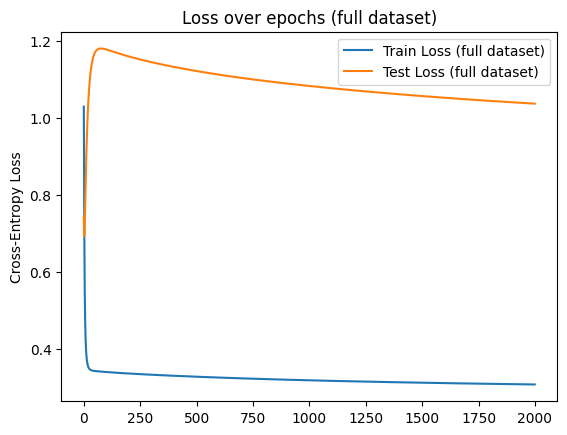

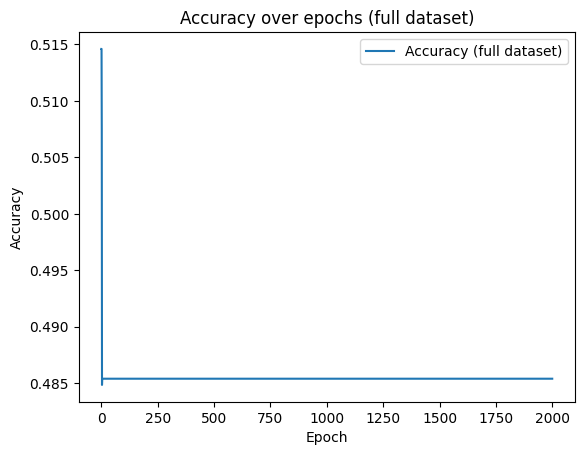

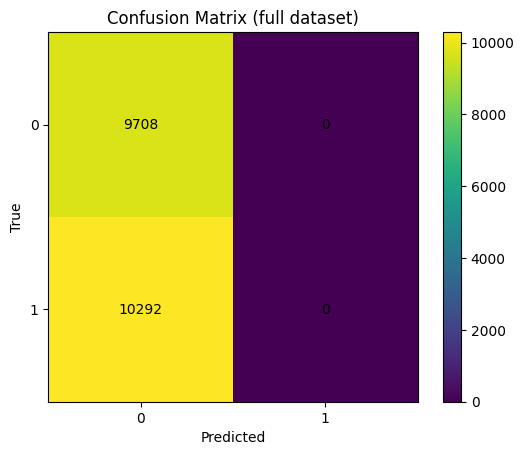

final full dataset accuracy: 0.48539999127388


In [ ]:
hidden_size = 64 # control this variable for now

# train the full dataset model 
full_model, full_accuracies = train_mlp(X_train_full, y_train_full, X_test, y_test, "full dataset", input_size, hidden_size, num_classes, device)
plot_confusion_matrix(full_model, X_test, y_test, "full dataset")
print(f"final full dataset accuracy: {full_accuracies[-1]}")

### Observations on full model
- Since the model trained on the full dataset tended to favor the majority class (non-diabetic) with significantly more samples, we can expect a lower sensitivity for detecting diabetes. It turned out that the final accuracy is 48.5%, which is even worse than flipping a coin, and suggests that the model trained on full dataset almost didn't work at all.
- Looking closer at the graphs, the cross-entropy loss on train set drops quickly to a low number, but the loss on test set jumps up at the beginning, slowly decreases, and still ends up at a high value. This suggests that the model is overfitting and thus perform very poorly on test data.
- The confusion matrix further proves the overfitting. In fact, the model never predicts a 1 (diabetic), so it's basically just classifying everyone into non-diabetic.

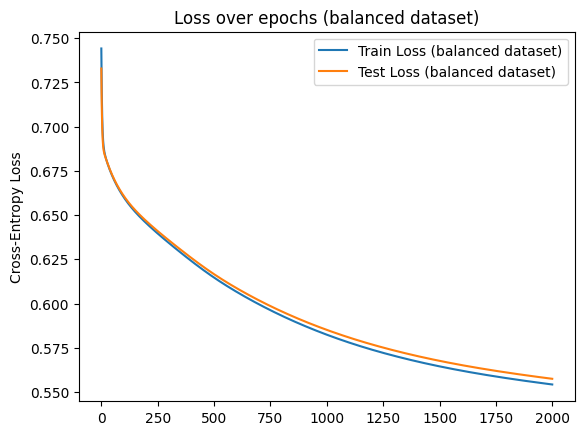

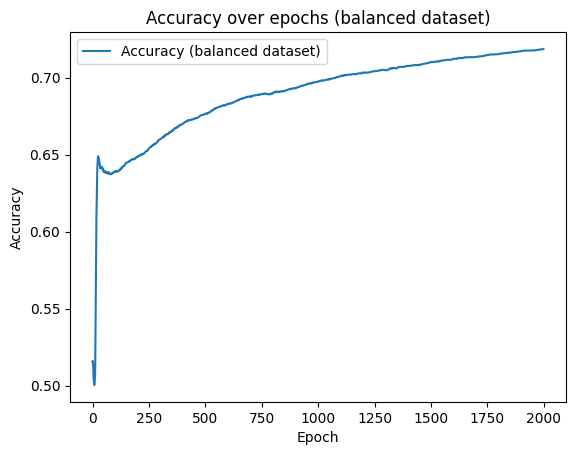

final balanced dataset accuracy: 0.71875


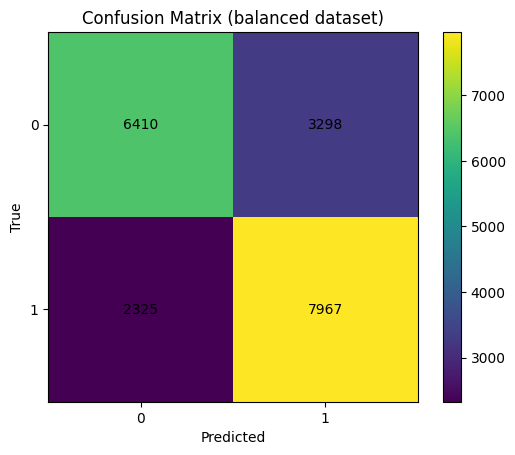

In [ ]:
# train the balanced dataset model
balanced_model, balanced_accuracies = train_mlp(X_train_bal, y_train_bal, X_test, y_test, "balanced dataset", input_size, hidden_size, num_classes, device)
print(f"final balanced dataset accuracy: {balanced_accuracies[-1]}")
plot_confusion_matrix(balanced_model, X_test, y_test, "balanced dataset")

### Observations on balanced model
- The model trained on the balanced dataset performed much better, providing more reliable predictions for the minority class (diabetic). The final accuracy is around 71.9%, which is decent and acceptable.
- The loss over epochs have good patterns of gradually decreasing for both train and test sets, and ended up at around 0.56.
- The confusion matrix has most samples correctly categorized as True Positives (TP) and True Negatives (TN). False Positives (TP) at top right is slightly more than False Negatives (FN), which suggests that it tends to misrecognize non-diabetes as diabetes a bit more than the other way around.

### Effectiveness and Limitations
The balanced model shows that the algorithm can learn useful patterns from the health indicators. With a final accuracy of about **71.9%**, it passed the evaluation criteria we set at the beginning. The confusion matrix shows many **true positives and true negatives**, suggesting the model captures meaningful relationships in the data.

The model trained on the full dataset performed poorly, reaching only **48.5%** accuracy on the test set and failing to predict any diabetic cases. This indicates that the model overfit the training data and was strongly biased toward the majority class. 

On the one hand, this demonstrated a good difference between the two models, which meets the other evaluation goal; on the other, since the full dataset model failed to work, we will have to only focus on the balanced dataset model in the following experiments.

## Hidden Layer Size

The hidden layer size was varied to analyze its effect on model accuracy, learning speed, and computational cost. Sizes tested:

10, 30, 50, 70, 90, 110, 130

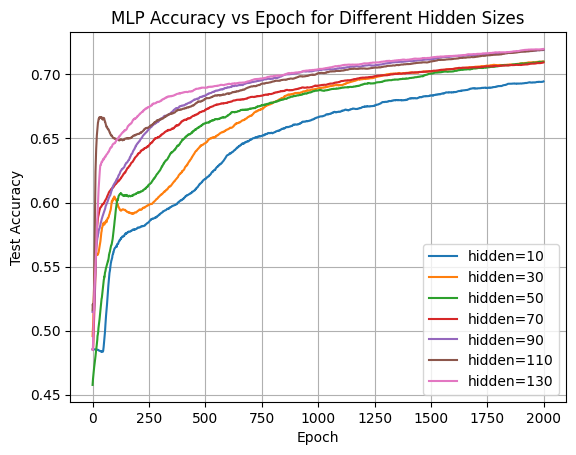

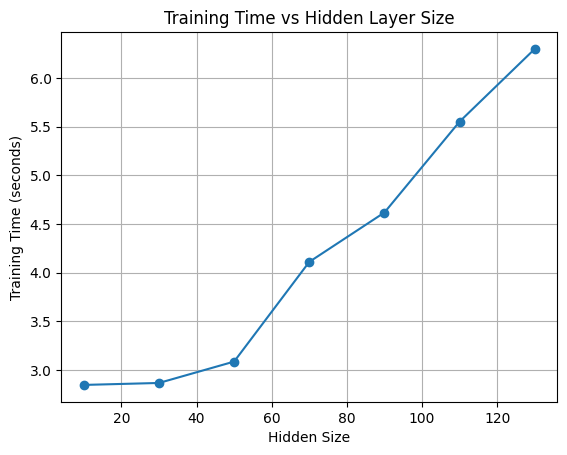

In [ ]:
# Hidden layer sizes to evaluate
hidden_sizes = list(range(10, 131, 20))  # 10, 30, 50, ..., 130

all_accuracies = {}  # accuracy curves for each hidden size
times = [] # training time for each model

for h in hidden_sizes:
    start = time.time()

    # Train model with current hidden size
    model, acc = train_mlp(
        X_train_bal, y_train_bal, X_test, y_test,
        f"hidden={h}", input_size, h, num_classes, device,
        plot=False
    )

    end = time.time() 

    # Store results
    all_accuracies[h] = acc
    times.append(end - start)

# Plot accuracy vs epoch for all hidden sizes
plt.figure()
for h, acc in all_accuracies.items():
    plt.plot(range(len(acc)), acc, label=f'hidden={h}')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('MLP Accuracy vs Epoch for Different Hidden Sizes')
plt.legend()
plt.grid(True)
plt.show()

# Plot training time vs hidden layer size
plt.figure()
plt.plot(hidden_sizes, times, marker='o')
plt.xlabel('Hidden Size')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs Hidden Layer Size')
plt.grid(True)
plt.show()

### Observations
- There's trade-off between performance and computational cost.
    - Increasing the hidden layer size generally improved model performance (first graph). Larger networks tended to reach good accuracy faster during training and often achieved higher final accuracy compared to smaller networks. 
    - Increasing hidden layer size also significantly increased the training time (second graph). Starting from the a size of 5, the increase appears to be linear.

- Starting around a hidden size of 70, accuracy improvements became minimal while the training time increased stably.

- For this dataset, which has 21 input features, a hidden layer size between 30 and 70 is a good choice. This range provides strong accuracy while keeping training time reasonable. The final choice within this range depends on whether faster training or slightly better accuracy is preferred.

# Conclusion

This notebook explored predicting diabetes using a Multilayer Perceptron neural network trained on health indicator data. The experiments focused on understanding how dataset balance and hidden layer size affect model performance.

One important takeaway is that dataset balancing plays an important role in classification performance. Training on a full dataset with unprocessed real-world data might fail to produce meaningful results. Also, model architecture influences accuracy and efficiency. Increasing the hidden layer size generally improved accuracy and allowed the model to reach good performance more quickly. However, larger networks also required more computation time.
